# Industrial System Sensor Data Analysis
<br>
Objective:
<br>
To analyze the behavior of an industrial tank-pump-valve system:
<br>
1. Descriptive Analysis: What patterns distinguish normal from abnormal operational states?
<br>
2. Diagnostics: How do system components interact — e.g., which pumps and valves influence specific tank levels or flow sensors?
<br>
3. Predictive Modeling: Can we train a machine learning model to accurately predict the system’s operational state (Label) based on real-time sensor readings?
<br>
<br>
Data Source:
<br>
Collected from an automated industrial monitoring system, containing timestamped readings of tank levels, pump states, valve activations, flow sensor outputs, and labeled system states.
<br> <br>
File: phy_att_1.csv

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
try:
    df = pd.read_csv('/content/phy_att_1.csv', sep="\t", encoding='utf-16', engine="python")
except UnicodeDecodeError:
        print("UnicodeDecodeError")

## Phase I - Basic Inspection
Data Quality Issues -> missing values, unexpected ranges, pumps/valves mostly on or off?

In [90]:
# Initial Overview
print(df.head())

                  Time  Tank_1  Tank_2  Tank_3  Tank_4  Tank_5  Tank_6  \
0  09/04/2021 18:23:28       0       0       0       0       0       0   
1  09/04/2021 18:23:29       0       0       0       0       0       0   
2  09/04/2021 18:23:30       0       0       0       0       0       0   
3  09/04/2021 18:23:31       0       0       0       0       0       0   
4  09/04/2021 18:23:32       0       0       0       0       0       0   

   Tank_7  Tank_8  Pump_1  ...  Valv_15  Valv_16  Valv_17  Valv_18  Valv_19  \
0       0       0   False  ...    False    False    False    False    False   
1       0       0   False  ...    False    False    False    False    False   
2       0       0   False  ...    False    False    False    False    False   
3       0       0   False  ...    False    False    False    False    False   
4       0       0    True  ...    False    False    False    False    False   

   Valv_20  Valv_21  Valv_22  Label_n   Label  
0    False    False    False    

In [150]:
# Conver time to datetime and examine the frequency to see if readings are continuous
df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time")
print(df["Time"].min(), df["Time"].max())
print(df["Time"].diff().describe())

2021-09-04 18:23:28 2021-09-04 19:03:47
count               2419
mean     0 days 00:00:01
std      0 days 00:00:00
min      0 days 00:00:01
25%      0 days 00:00:01
50%      0 days 00:00:01
75%      0 days 00:00:01
max      0 days 00:00:01
Name: Time, dtype: object


The dataset spans about 40 minutes of the system's activity, and the data is recorded at a one-second frequency. Sampling is consistent, no timestamps are missing. There are also no irregular gaps or dropped samples.

In [149]:
# General data structures
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2420 entries, 0 to 2419
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Time           2420 non-null   datetime64[ns]
 1   Tank_1         2420 non-null   int64         
 2   Tank_2         2420 non-null   int64         
 3   Tank_3         2420 non-null   int64         
 4   Tank_4         2420 non-null   int64         
 5   Tank_5         2420 non-null   int64         
 6   Tank_6         2420 non-null   int64         
 7   Tank_7         2420 non-null   int64         
 8   Tank_8         2420 non-null   int64         
 9   Pump_1         2420 non-null   bool          
 10  Pump_2         2420 non-null   bool          
 11  Pump_4         2420 non-null   bool          
 12  Pump_5         2420 non-null   bool          
 13  Pump_6         2420 non-null   bool          
 14  Flow_sensor_1  2420 non-null   int64         
 15  Flow_sensor_2  2420 n

In [92]:
print(df.columns.tolist())

['Time', 'Tank_1', 'Tank_2', 'Tank_3', 'Tank_4', 'Tank_5', 'Tank_6', 'Tank_7', 'Tank_8', 'Pump_1', 'Pump_2', 'Pump_3', 'Pump_4', 'Pump_5', 'Pump_6', 'Flow_sensor_1', 'Flow_sensor_2', 'Flow_sensor_3', 'Flow_sensor_4', 'Valv_1', 'Valv_2', 'Valv_3', 'Valv_4', 'Valv_5', 'Valv_6', 'Valv_7', 'Valv_8', 'Valv_9', 'Valv_10', 'Valv_11', 'Valv_12', 'Valv_13', 'Valv_14', 'Valv_15', 'Valv_16', 'Valv_17', 'Valv_18', 'Valv_19', 'Valv_20', 'Valv_21', 'Valv_22', 'Label_n', 'Label']


In [122]:

# Cleaning and Preprocessing
df.isnull().sum().sort_values(ascending=False)

,0
Time,0
Tank_1,0
Tank_2,0
Tank_3,0
Tank_4,0
Tank_5,0
Tank_6,0
Tank_7,0
Tank_8,0
Pump_1,0


In [124]:
df.describe(include='all')

,Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,...,Valv_16,Valv_17,Valv_18,Valv_19,Valv_20,Valv_21,Valv_22,Label_n,Label,Label_encoded
count,2420,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420.000000,2420,...,2420,2420,2420,2420,2420,2420,2420,2420.000000,2420,2420.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,1,2,2,1,2,1,2,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,False,False,True,False,False,NaN,normal,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1694,...,2420,1486,1861,2420,1500,2420,1372,NaN,1610,NaN
mean,2021-09-04 18:43:37.500000,686.320661,714.946281,922.677686,362.064463,361.733058,198.284298,207.890083,163.835124,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.334711,NaN,0.894215
min,2021-09-04 18:23:28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
25%,2021-09-04 18:33:32.750000128,2.000000,5.000000,73.250000,27.000000,30.500000,3.000000,0.000000,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000
50%,2021-09-04 18:43:37.500000,598.000000,639.500000,747.500000,231.000000,370.000000,165.500000,144.000000,86.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000
75%,2021-09-04 18:53:42.249999872,1244.000000,1293.250000,1226.250000,692.250000,605.250000,380.250000,450.000000,358.250000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000
max,2021-09-04 19:03:47,1980.000000,1952.000000,3427.000000,1134.000000,835.000000,800.000000,812.000000,507.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,2.000000


In [130]:
# Remove any column with no variation
low_var_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Low-variance columns:", low_var_cols)
df = df.drop(columns=low_var_cols)

Low-variance columns: ['Pump_3', 'Flow_sensor_3', 'Valv_1', 'Valv_2', 'Valv_3', 'Valv_4', 'Valv_5', 'Valv_6', 'Valv_7', 'Valv_8', 'Valv_9', 'Valv_16', 'Valv_19', 'Valv_21']


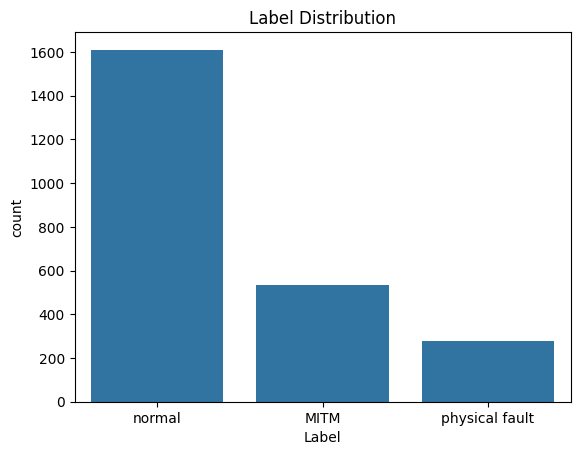

In [131]:
# Check label distribution for class imbalance
sns.countplot(x='Label', data=df)
plt.title("Label Distribution")
plt.show()

The "normal" class dominates, so we could probably downsample the majority class or oversample the minority class using SMOTE.

## Phase II - Descriptive Visualization
Trends over time

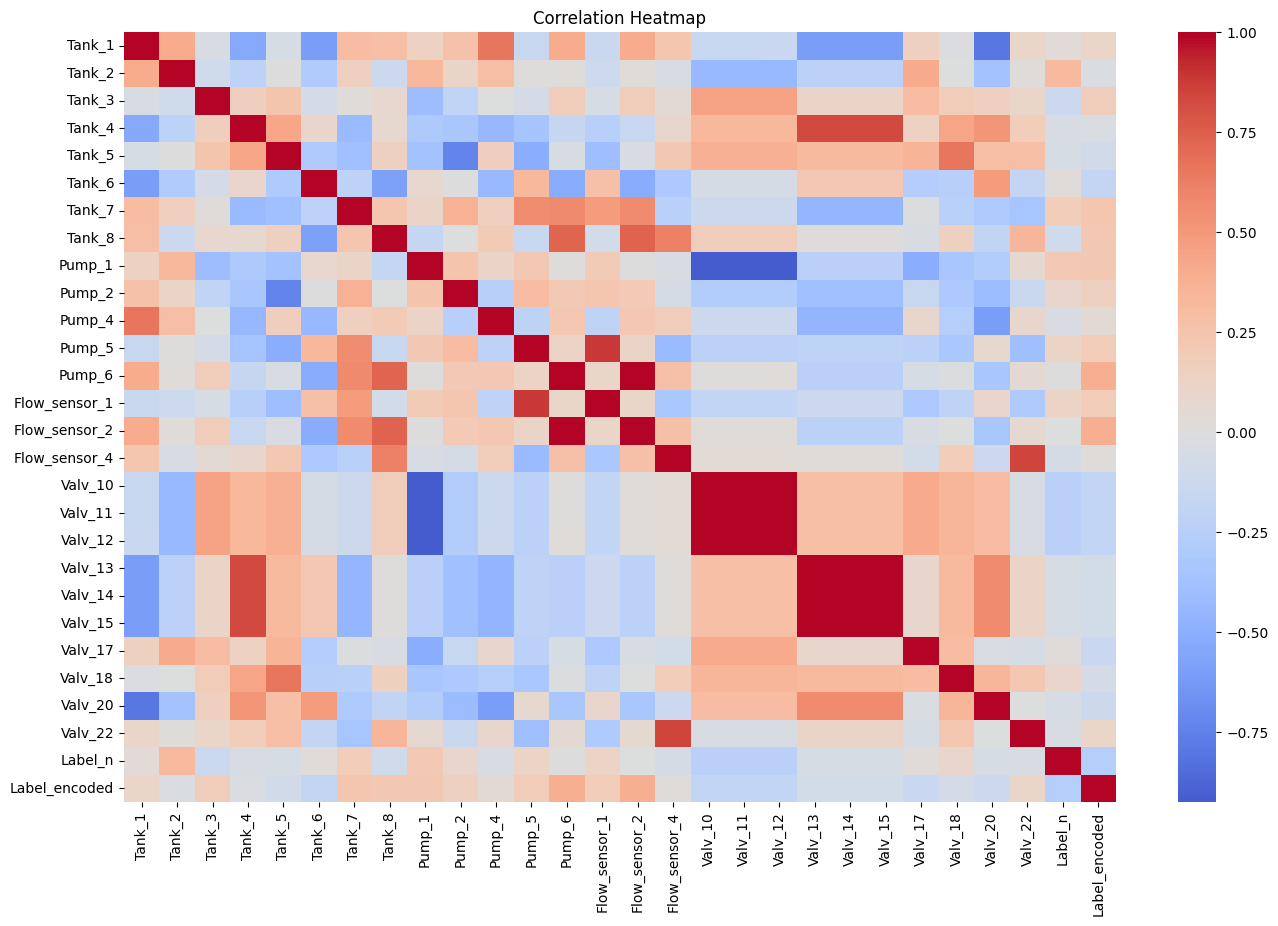

In [132]:
# See how sensor readings and actuators relate to each other
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

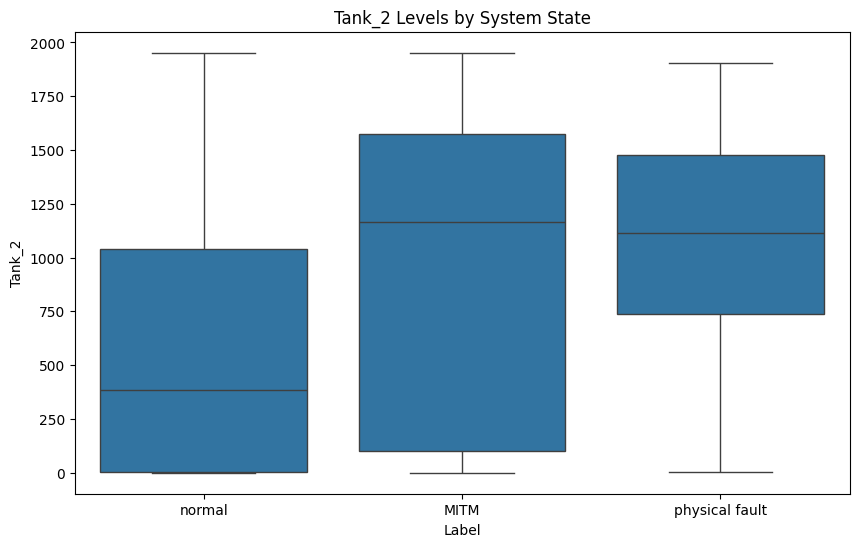

In [145]:
# Compare tanks levels for different system states (features across labels)
## Repeat for a few tanks and flow sensors
plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y='Tank_2', data=df)
plt.title('Tank_2 Levels by System State')
plt.show()

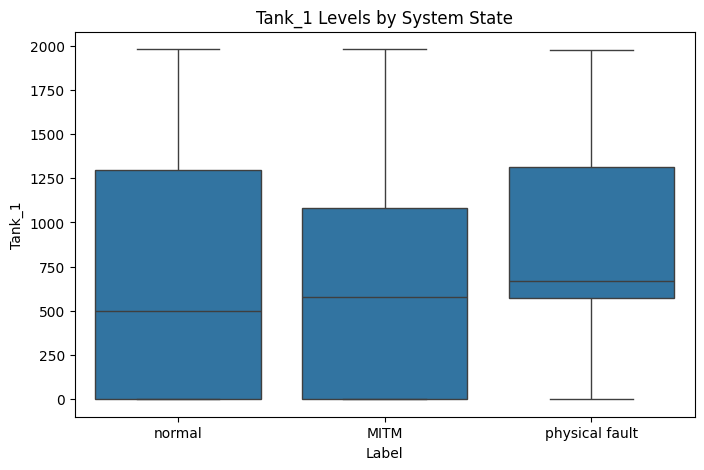

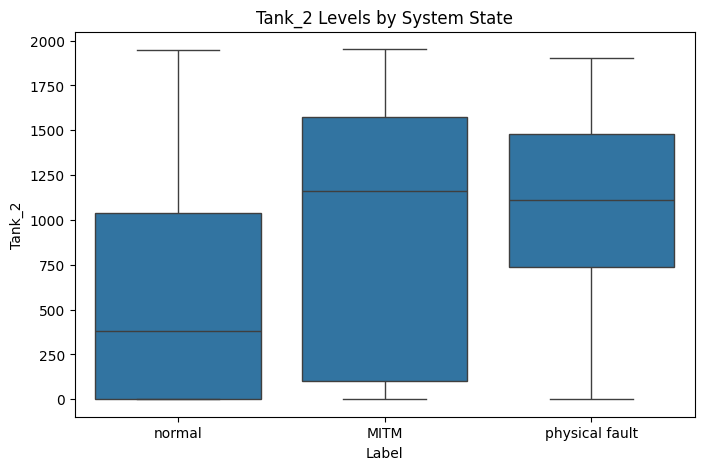

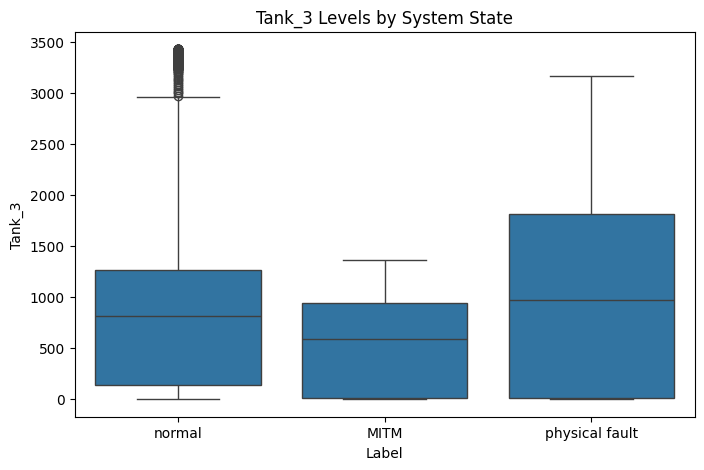

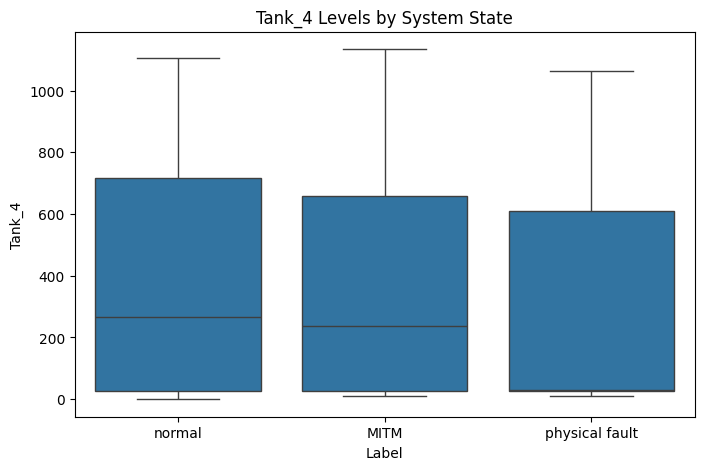

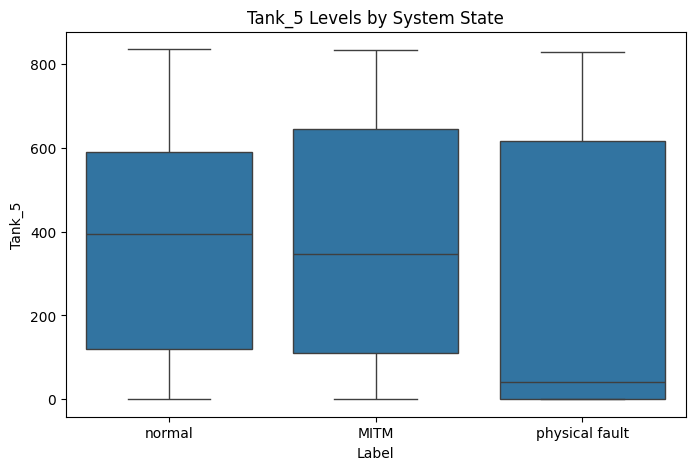

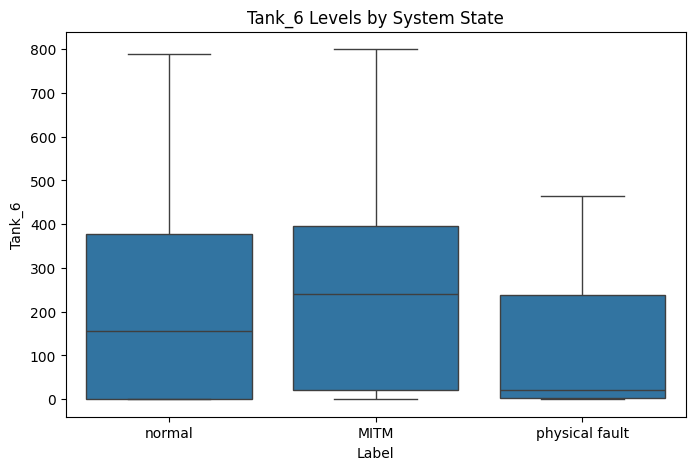

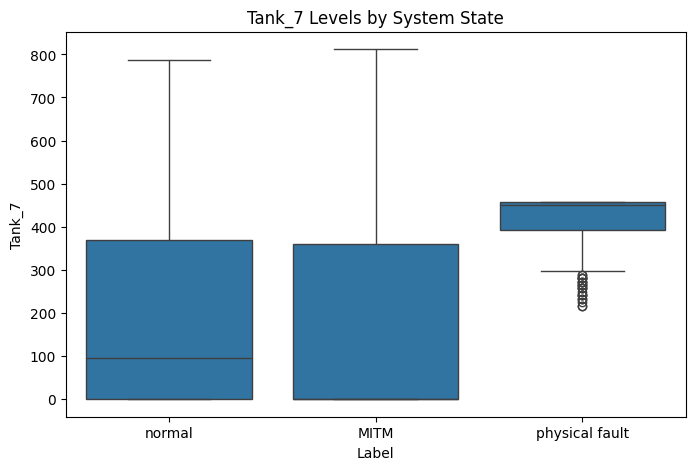

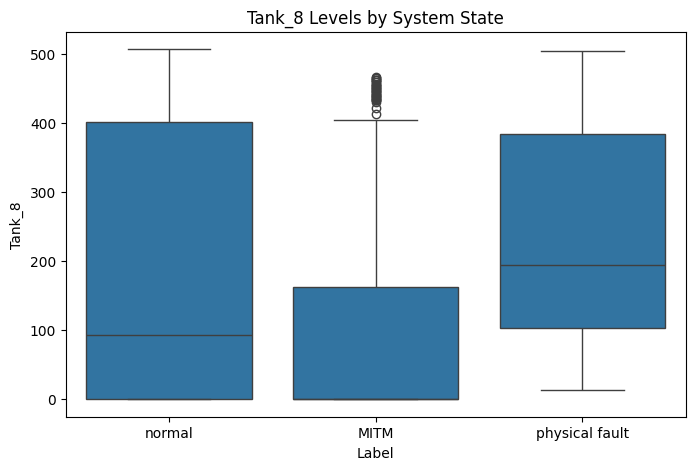

In [146]:
# Compare across tanks
for col in [c for c in df.columns if "Tank" in c]:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Label", y=col, data=df)
    plt.title(f"{col} Levels by System State")
    plt.show()

Tank 1 -> Generally healthy range of operation, not severely affected even under MITM; these control loops may be resilient to data tampering, only physical fault shows some impact, possibly slower drainage or overfilling
<br>
Tank 2 -> Similarly healthy range of operation with higher median level
<br>
Tank 3 -> Under MITM conditions, behavior is more constrained, possibly either manipulated or sensor-fed with limited variation; strong physical disturbance pattern when overfilled or emptied erratically
<br>
Tank 4 -> Minorly impacted by physical fault, yet holds some resilience to data tampering
<br>
Tank 5 -> Generally high levels and healthy range of operation
<br>
Tank 6 -> Resilient to data tampering, similar to Tank_1
<br>
Tank 7 -> Sensitive to physical faults and wide variation under MITM, yet holds similar levels to Tank_8 under normal conditions
<br>
Tank 8 -> Sensitive to MITM more than physical faults

In [148]:
# Compare across pumps and valves
df_corr = df.corr(numeric_only=True)
print(df_corr['Tank_1'].sort_values(ascending=False).head(10))

Tank_1           1.000000
Pump_4           0.658705
Flow_sensor_2    0.402162
Pump_6           0.399320
Tank_2           0.398673
Tank_7           0.307224
Tank_8           0.291134
Pump_2           0.264954
Flow_sensor_4    0.233363
Valv_17          0.154651
Name: Tank_1, dtype: float64


In [143]:
# Verify Label differences are significant
# Repeat for other tanks and sensors to see system state responses
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    df[df['Label']=='normal']['Tank_4'],
    df[df['Label']=='MITM']['Tank_4'],
    df[df['Label']=='physical fault']['Tank_4']
)

print(p_value)  # p < 0.05 = statistically significant difference

0.01280734926940001


## Phase III - System Behavior Analysis
Event detection

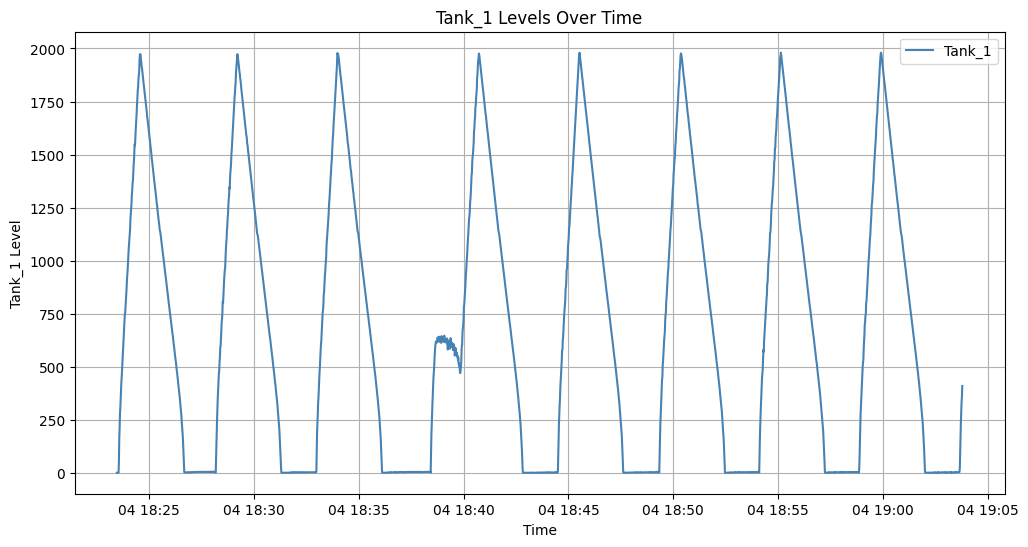

In [154]:
# Plot single tank levels over time, especially during normal and faulty states
import matplotlib.pyplot as plt

# Sort by time (just in case)
df = df.sort_values('Time')

# Plot one tank over time
plt.figure(figsize=(12,6))
plt.plot(df['Time'], df['Tank_1'], label='Tank_1', color='steelblue')
plt.title('Tank_1 Levels Over Time')
plt.xlabel('Time')
plt.ylabel('Tank_1 Level')
plt.legend()
plt.grid(True)
plt.show()

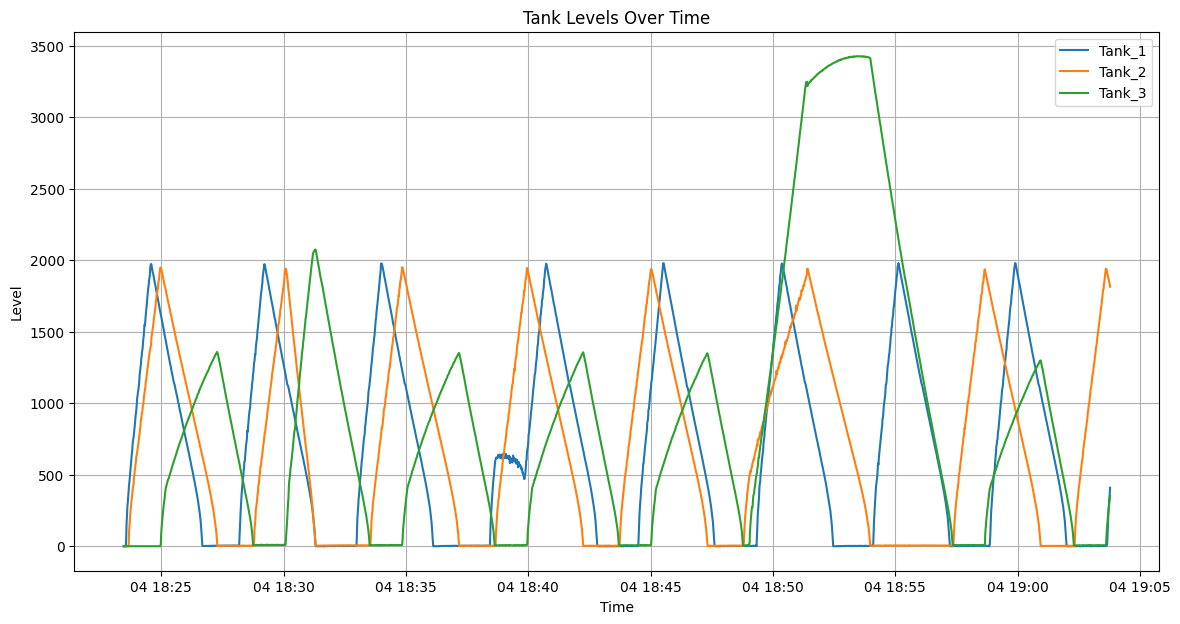

In [155]:
# For multiple tanks
plt.figure(figsize=(14,7))
plt.plot(df['Time'], df['Tank_1'], label='Tank_1')
plt.plot(df['Time'], df['Tank_2'], label='Tank_2')
plt.plot(df['Time'], df['Tank_3'], label='Tank_3')
plt.title('Tank Levels Over Time')
plt.xlabel('Time')
plt.ylabel('Level')
plt.legend()
plt.grid(True)
plt.show()

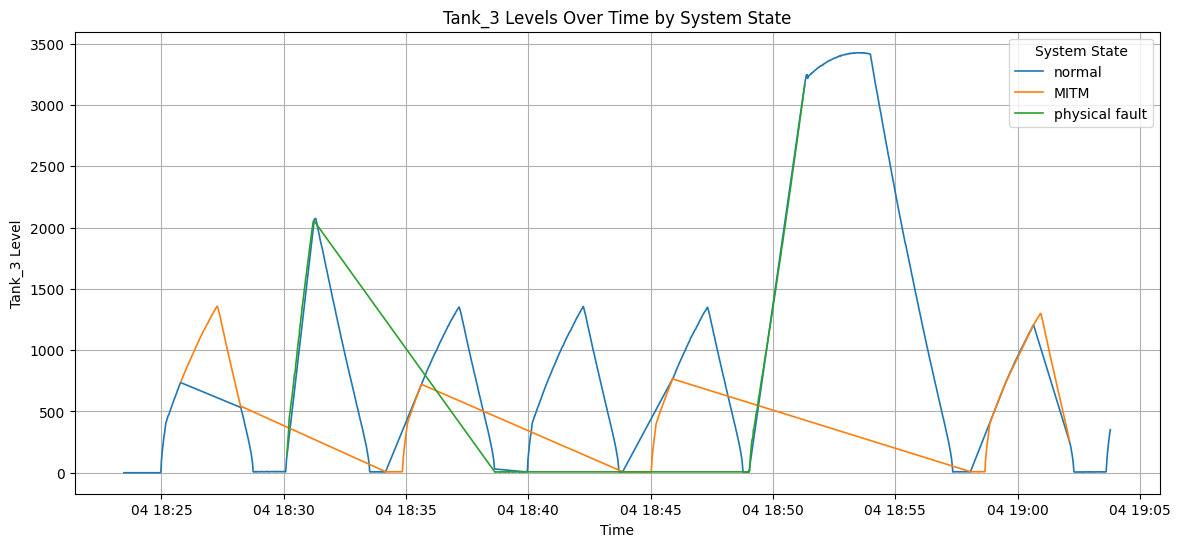

In [156]:
# System behavior under different operating states
plt.figure(figsize=(14,6))
sns.lineplot(x='Time', y='Tank_3', hue='Label', data=df, linewidth=1.2)
plt.title('Tank_3 Levels Over Time by System State')
plt.xlabel('Time')
plt.ylabel('Tank_3 Level')
plt.legend(title='System State')
plt.grid(True)
plt.show()

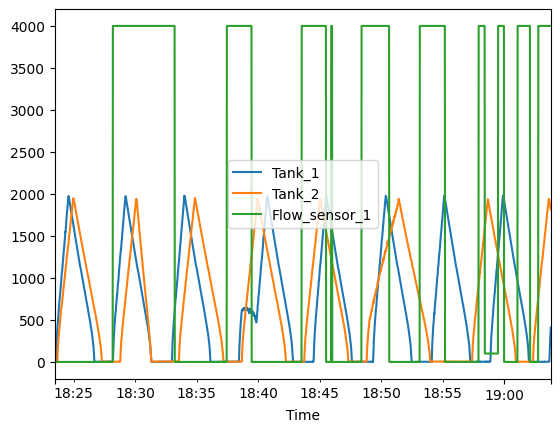

In [99]:
# Plot a few key variables to see how tank levels and flows change
df.plot(x="Time", y=["Tank_1", "Tank_2", "Flow_sensor_1"])
plt.show()

<Axes: >

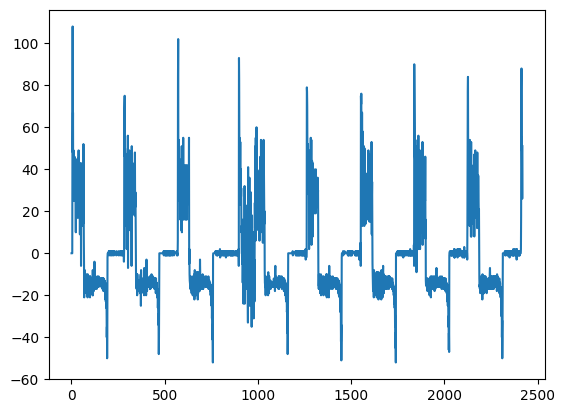

In [102]:
# Look for sudden changes by filtering for major jumps, like potential pump/valve actions
df["Tank_1"].diff().plot()

In [103]:
# Check for relationships by testing hypotheses
# Pump_1 increase = Flow_sensor_1 increase?
df.groupby("Pump_1")["Flow_sensor_1"].mean()

,Flow_sensor_1
Pump_1,
False,1377.213695
True,2233.471074


In [104]:
# Valv_5 = 1, Tank_3 level = what?
df.groupby("Valv_5")["Tank_3"].mean()

,Tank_3
Valv_5,
False,922.677686


## Phase IV - Machine Learning
Focus on labels

In [105]:
from sklearn.preprocessing import LabelEncoder
# Encode categorical labels
le = LabelEncoder()
df["Label_encoded"] = le.fit_transform(df["Label"])

In [106]:
# Train-test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Time", "Label", "Label_encoded"])
y = df["Label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Which sensors or pumps most strongly determine the system's labels?

In [107]:
# Decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       106
           1       1.00      1.00      1.00       318
           2       1.00      0.98      0.99        60

    accuracy                           1.00       484
   macro avg       1.00      0.99      1.00       484
weighted avg       1.00      1.00      1.00       484



## Phase V - Advanced Analytics
Time-series prediction (LSTM and rolling windows to forecast next state)
<br>
Anomaly detection (isolation forest or autoencdoer to flag unusual behavior)
<br>
Feature importance visualization (which tanks/valves affect outcomes most)

### Univariate Analysis

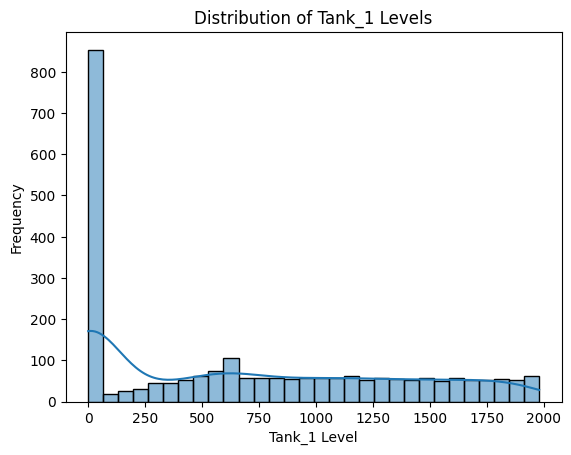

In [157]:
# Visualize tank levels
sns.histplot(df["Tank_1"], kde=True, bins=30)
plt.title("Distribution of Tank_1 Levels")
plt.xlabel("Tank_1 Level")
plt.ylabel("Frequency")
plt.show()

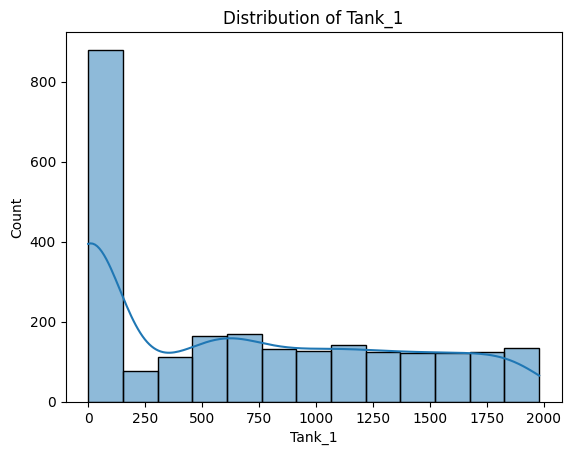

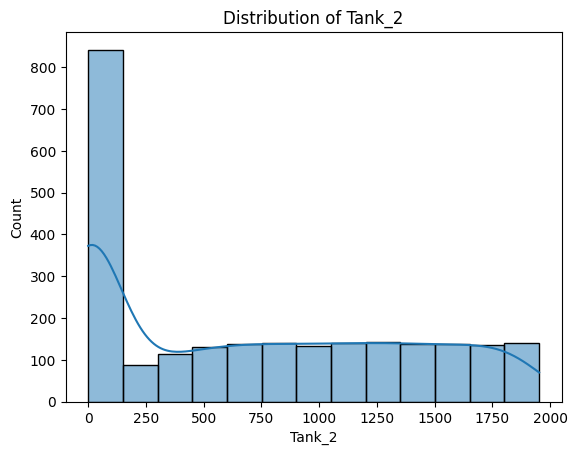

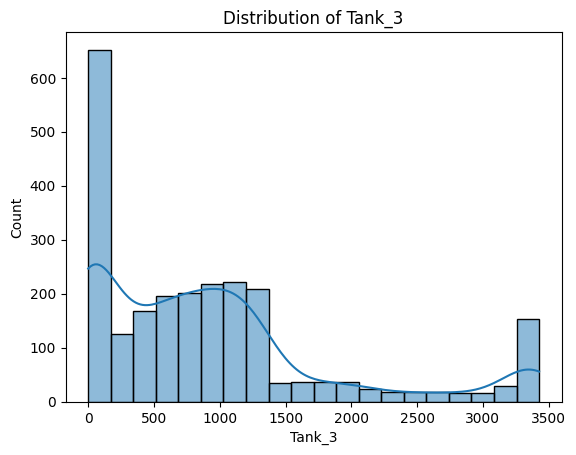

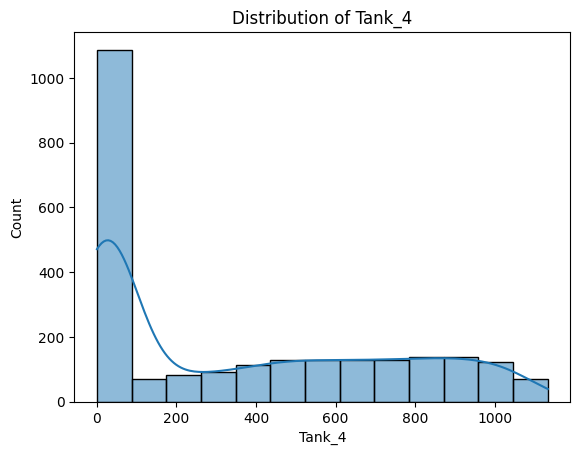

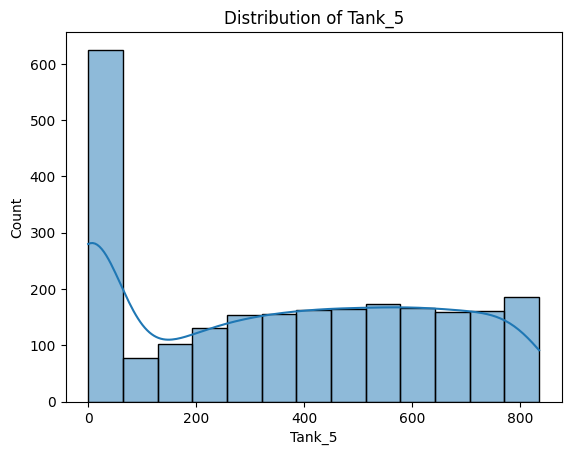

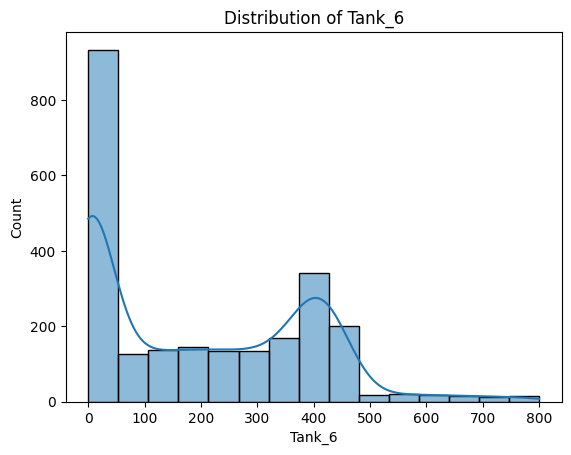

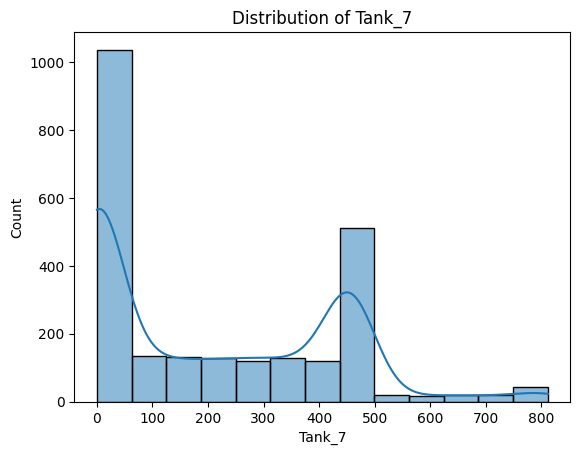

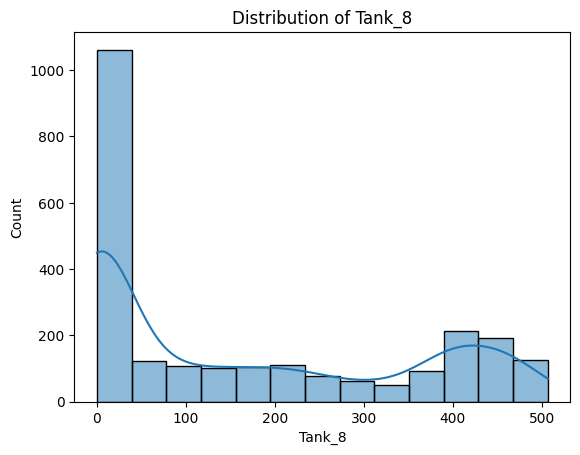

In [109]:
# Compare multiple similar columns
tank_cols = [col for col in df.columns if "Tank" in col]

for col in tank_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

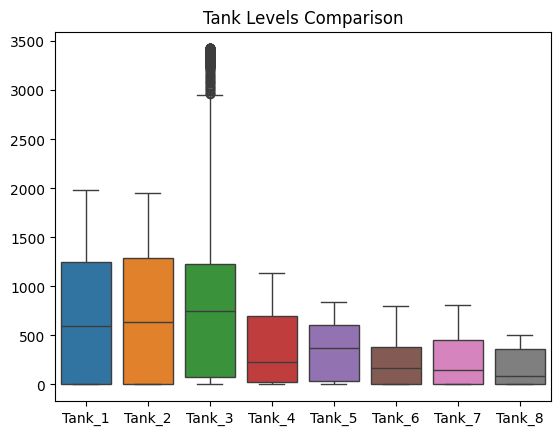

In [111]:
# Multiple tank comparison of boxplots
sns.boxplot(data=df[tank_cols])
plt.title("Tank Levels Comparison")
plt.show()

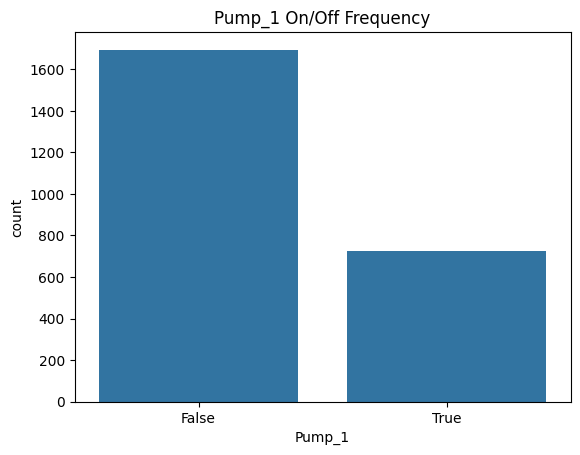

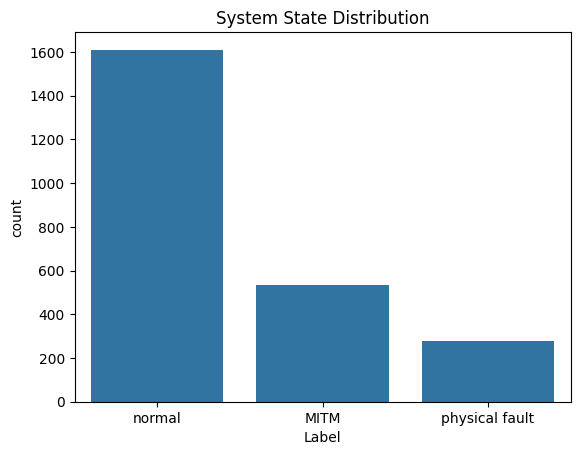

In [112]:
# Histograms not useful for binary data, initialize count plot for categorical variables
pump_cols = [col for col in df.columns if "Pump" in col]
sns.countplot(x="Pump_1", data=df)
plt.title("Pump_1 On/Off Frequency")
plt.show()

sns.countplot(x="Label", data=df)
plt.title("System State Distribution")
plt.show()

### Bivariate Analysis

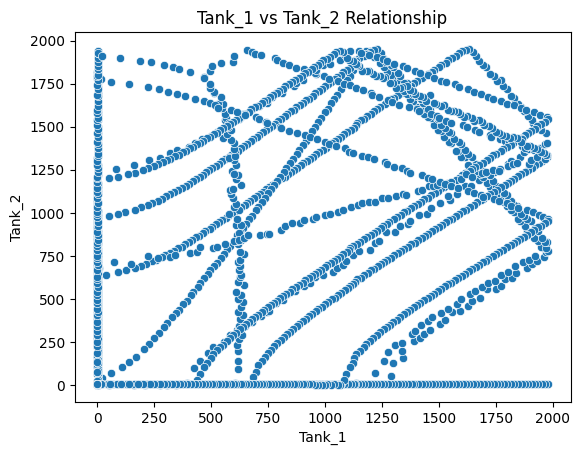

                 Tank_1    Tank_2    Tank_3    Tank_4    Tank_5    Tank_6  \
Tank_1         1.000000  0.398673 -0.040350 -0.529771 -0.046427 -0.607198   
Tank_2         0.398673  1.000000 -0.092597 -0.220631  0.005584 -0.288781   
Tank_3        -0.040350 -0.092597  1.000000  0.167165  0.245427 -0.062380   
Tank_4        -0.529771 -0.220631  0.167165  1.000000  0.429545  0.095655   
Tank_5        -0.046427  0.005584  0.245427  0.429545  1.000000 -0.299987   
Tank_6        -0.607198 -0.288781 -0.062380  0.095655 -0.299987  1.000000   
Tank_7         0.307224  0.160250  0.016448 -0.428223 -0.385502 -0.220434   
Tank_8         0.291134 -0.131609  0.077393  0.068809  0.155908 -0.588535   
Pump_1         0.137978  0.326358 -0.409422 -0.304185 -0.369667  0.082038   
Pump_2         0.264954  0.111680 -0.199873 -0.339441 -0.734146  0.004306   
Pump_3              NaN       NaN       NaN       NaN       NaN       NaN   
Pump_4         0.658705  0.287497 -0.006887 -0.436827  0.172587 -0.429819   

In [113]:
# Correlation matrix to show how strongly numeric variables move together
sns.scatterplot(x="Tank_1", y="Tank_2", data=df)
plt.title("Tank_1 vs Tank_2 Relationship")
plt.show()

print(df.corr(numeric_only=True))

In [114]:
# Cross tabulation to count how many times each combination occurred
pd.crosstab(df["Pump_1"], df["Label"], margins=True)

Label,MITM,normal,physical fault,All
Pump_1,,,,
False,387,1240,67,1694
True,146,370,210,726
All,533,1610,277,2420


In [115]:
# Chi-Square Independence Test to show whether the two categorical variables are related
# p < 0.05 = significantly related
# p >= 0.05 = no strong evidence
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["Pump_1"], df["Label"])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square Statistic:", chi2)
print("p-value:", p)

# Interpret the results
alpha = 0.05
if p < alpha:
    print("\nResult: The variables are likely dependent (reject H0).")
else:
    print("\nResult: The variables are likely independent (fail to reject H0).")

Chi-square Statistic: 316.3301303974991
p-value: 2.0407272059503265e-69

Result: The variables are likely dependent (reject H0).


In [116]:
# Loop through all pump/valve columns to find which are most related to abnormal system state label
cat_cols = [col for col in df.columns if "Pump" in col or "Valv" in col]

for col in cat_cols:
    table = pd.crosstab(df[col], df["Label"])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p:.4f}")

Pump_1: p-value = 0.0000
Pump_2: p-value = 0.0000
Pump_3: p-value = 1.0000
Pump_4: p-value = 0.0348
Pump_5: p-value = 0.0000
Pump_6: p-value = 0.0000
Valv_1: p-value = 1.0000
Valv_2: p-value = 1.0000
Valv_3: p-value = 1.0000
Valv_4: p-value = 1.0000
Valv_5: p-value = 1.0000
Valv_6: p-value = 1.0000
Valv_7: p-value = 1.0000
Valv_8: p-value = 1.0000
Valv_9: p-value = 1.0000
Valv_10: p-value = 0.0000
Valv_11: p-value = 0.0000
Valv_12: p-value = 0.0000
Valv_13: p-value = 0.0000
Valv_14: p-value = 0.0000
Valv_15: p-value = 0.0000
Valv_16: p-value = 1.0000
Valv_17: p-value = 0.0000
Valv_18: p-value = 0.0000
Valv_19: p-value = 1.0000
Valv_20: p-value = 0.0000
Valv_21: p-value = 1.0000
Valv_22: p-value = 0.0000


In [117]:
# Compute pathwise correlations between numeric columns to see how strongly related two tank levels are
boolean_correlation = df[['Tank_1', 'Tank_2']].corr()
print(boolean_correlation)

          Tank_1    Tank_2
Tank_1  1.000000  0.398673
Tank_2  0.398673  1.000000


In [118]:
# For all numeric columns
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                 Tank_1    Tank_2    Tank_3    Tank_4    Tank_5    Tank_6  \
Tank_1         1.000000  0.398673 -0.040350 -0.529771 -0.046427 -0.607198   
Tank_2         0.398673  1.000000 -0.092597 -0.220631  0.005584 -0.288781   
Tank_3        -0.040350 -0.092597  1.000000  0.167165  0.245427 -0.062380   
Tank_4        -0.529771 -0.220631  0.167165  1.000000  0.429545  0.095655   
Tank_5        -0.046427  0.005584  0.245427  0.429545  1.000000 -0.299987   
Tank_6        -0.607198 -0.288781 -0.062380  0.095655 -0.299987  1.000000   
Tank_7         0.307224  0.160250  0.016448 -0.428223 -0.385502 -0.220434   
Tank_8         0.291134 -0.131609  0.077393  0.068809  0.155908 -0.588535   
Pump_1         0.137978  0.326358 -0.409422 -0.304185 -0.369667  0.082038   
Pump_2         0.264954  0.111680 -0.199873 -0.339441 -0.734146  0.004306   
Pump_3              NaN       NaN       NaN       NaN       NaN       NaN   
Pump_4         0.658705  0.287497 -0.006887 -0.436827  0.172587 -0.429819   

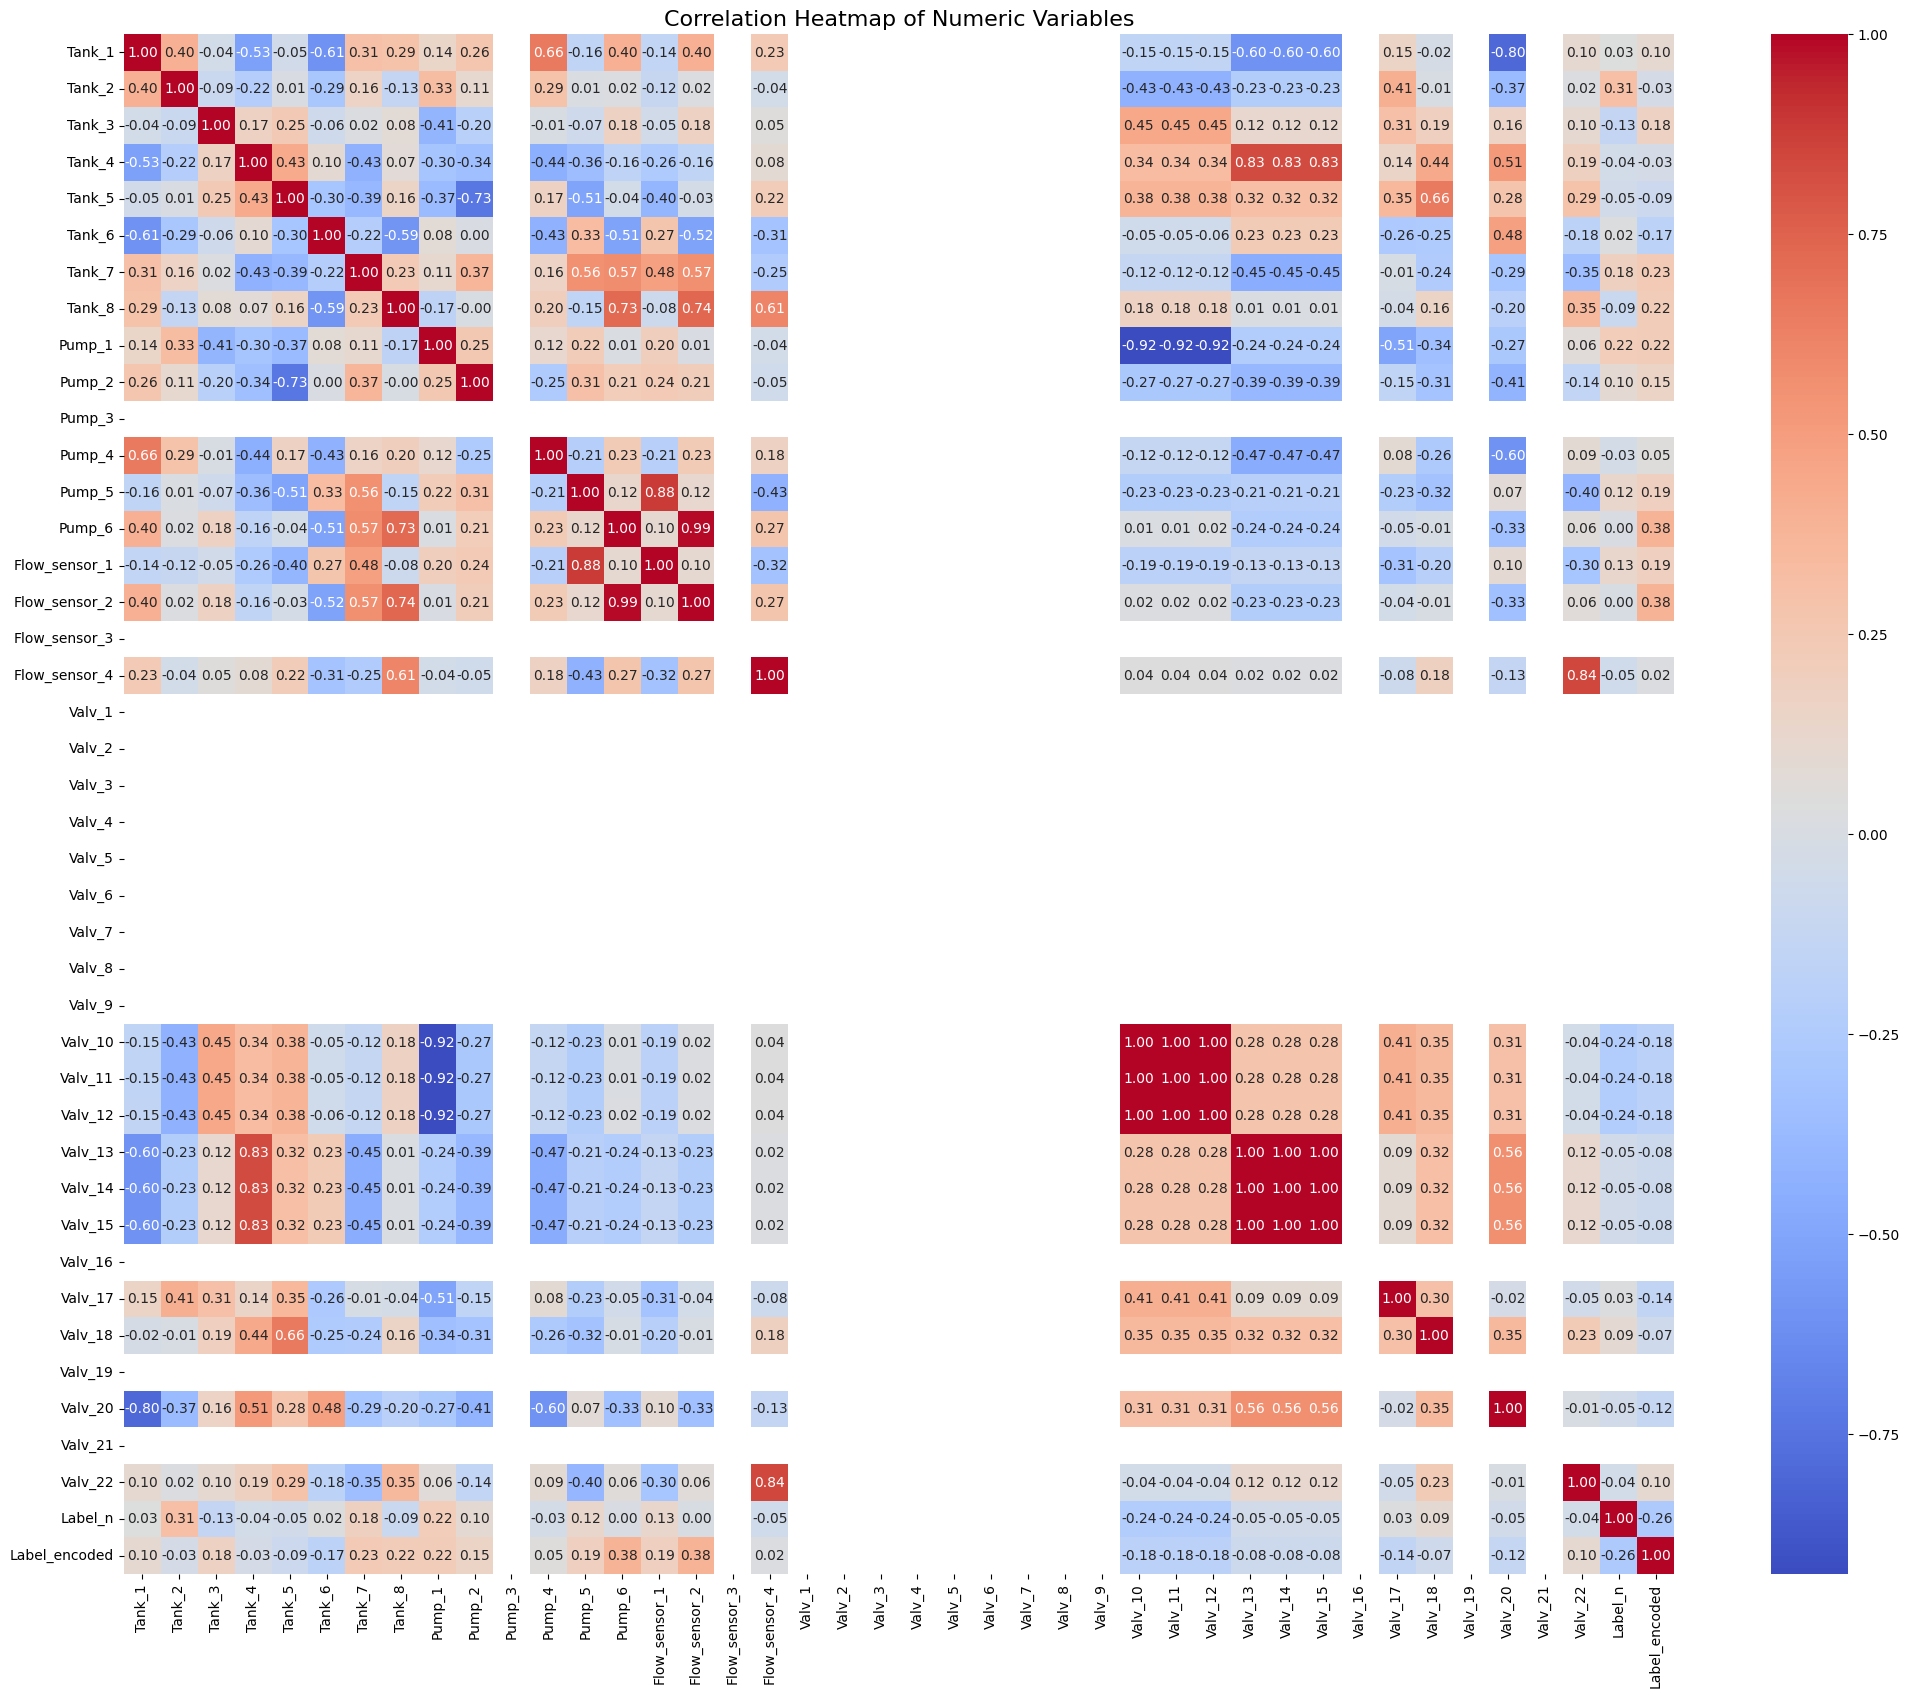

In [119]:
# Visualize correlation matrix to identify which sensors most corrrelated with system state
plt.figure(figsize=(25, 20))  # width=12 inches, height=8 inches
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables", fontsize=16)
plt.show()

# Predictive Modeling

In [135]:
X = df.drop(['Label', 'Label_encoded', 'Time'], axis=1)
y = df['Label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       1.00      1.00      1.00       318
           2       1.00      1.00      1.00        60

    accuracy                           1.00       484
   macro avg       1.00      1.00      1.00       484
weighted avg       1.00      1.00      1.00       484



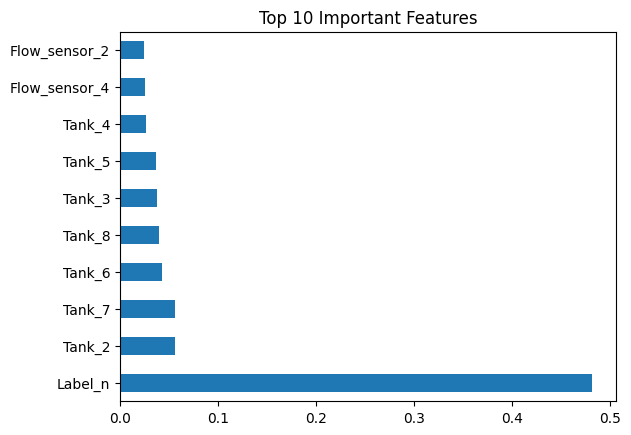

In [158]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()